# <span style="color:purple; font-weight:bold; text-decoration:underline;"> NPAC Sulfate Burden Climatologies and Differences

### <span style="color:purple"> Imports

In [8]:
import xarray as xr
import os
import utils
from utils.load_variable import load_variables_for_all_years
import wesanderson

### <span style="color:purple"> Area file and region mask

In [10]:
area = xr.open_dataarray('/glade/work/jzweifel/Regional_Masks_And_Area/area_files/AREA.nc')
NPAC_mask = xr.open_dataarray('/glade/work/jzweifel/Regional_Masks_And_Area/masks/NPAC/NPAC_mask.nc')

### <span style="color:purple"> Loading Sulfate and Burden variables

In [9]:
SFSO2 = load_variables_for_all_years('h0', 'SFSO2')
# units : kg/m2/s
# long_name : SO2 surface flux

BURDENSO4 = load_variables_for_all_years('h3', 'BURDENSO4')
# units : kg/m2
# long_name : Sulfate aerosol burden, day only

### <span style="color:purple"> Creating Monthly NPAC Climatologies

In [12]:
monthly_burden_1850 = (BURDENSO4['1850'].where(NPAC_mask)).weighted(area).mean(dim=['lat', 'lon']).groupby('time.month').mean(dim=['time']).roll(month=-1)
monthly_burden_1970 = (BURDENSO4['1970'].where(NPAC_mask)).weighted(area).mean(dim=['lat', 'lon']).groupby('time.month').mean(dim=['time']).roll(month=-1)
monthly_burden_2000 = (BURDENSO4['2000'].where(NPAC_mask)).weighted(area).mean(dim=['lat', 'lon']).groupby('time.month').mean(dim=['time']).roll(month=-1)
monthly_burden_2006 = (BURDENSO4['2006'].where(NPAC_mask)).weighted(area).mean(dim=['lat', 'lon']).groupby('time.month').mean(dim=['time']).roll(month=-1)

### <span style="color:purple"> Plotting Monthly NPAC Climatologies and Differences

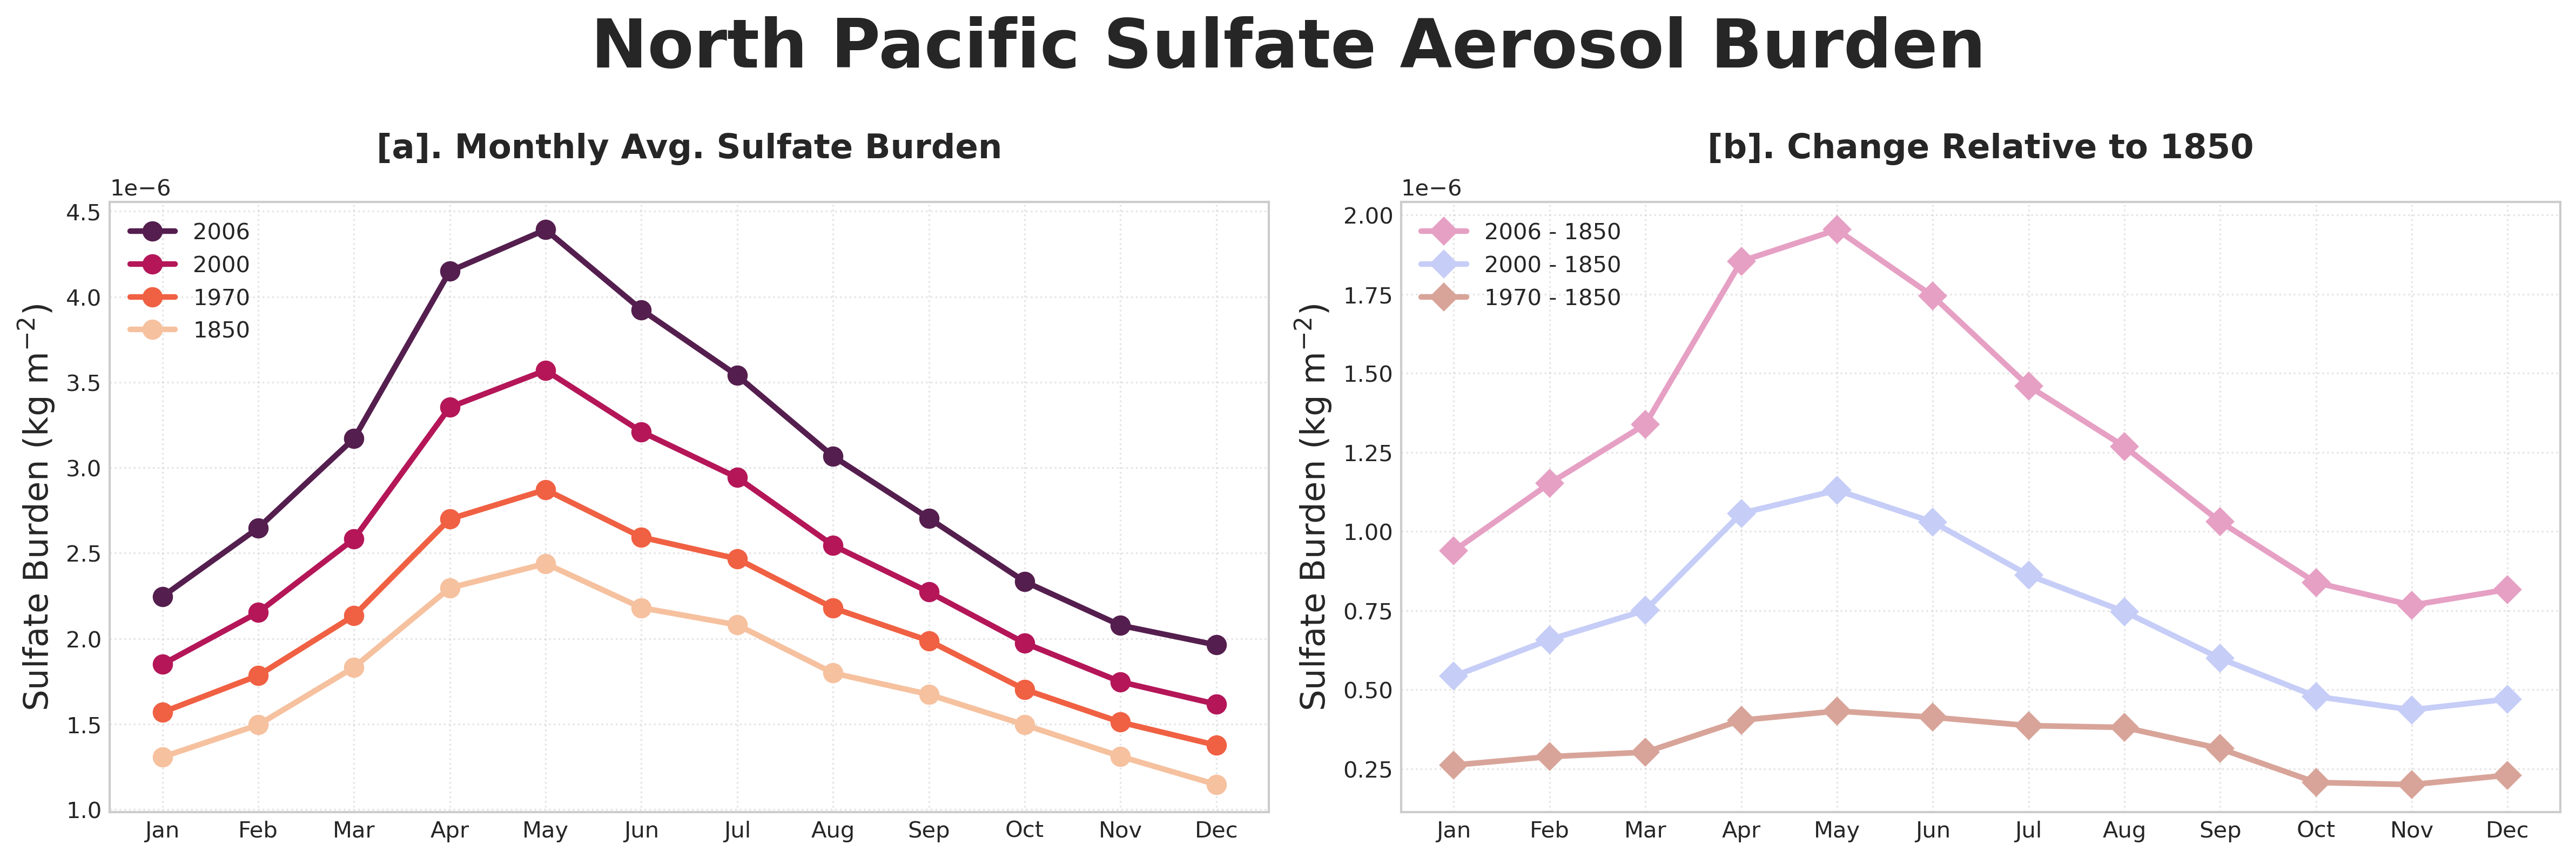

In [7]:
import matplotlib.pyplot as plt
import calendar
import seaborn as sns
import wesanderson

years = ["1850", "1970", "2000", "2006"]
months = [calendar.month_abbr[i] for i in range(1, 13)]

# -------------------------------------------------------------------
# Global style
# -------------------------------------------------------------------
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'legend.frameon': False,
    'lines.linewidth': 2.5,
    'axes.titleweight': 'bold'
})

# -------------------------------------------------------------------
# Rocket palette — EXACT same logic as your stacked figure
# -------------------------------------------------------------------
rocket4 = sns.color_palette("rocket", 8)[::-2][:4]
color_for = dict(zip(years, rocket4))

# Wes Anderson palette for anomaly panel (unchanged)
palette_2 = wesanderson.film_palette("Grand Budapest Hotel", 1)

# -------------------------------------------------------------------
# Create figure
# -------------------------------------------------------------------
fig, axs = plt.subplots(1, 2, figsize=(16, 5), dpi=300, sharey=False)

# ================================================================
# LEFT PANEL: Monthly Burden
# ================================================================
axs[0].plot(months, monthly_burden_2006, label='2006',
            color=color_for["2006"], marker='o', markersize=8)

axs[0].plot(months, monthly_burden_2000, label='2000',
            color=color_for["2000"], marker='o', markersize=8)

axs[0].plot(months, monthly_burden_1970, label='1970',
            color=color_for["1970"], marker='o', markersize=8)

axs[0].plot(months, monthly_burden_1850, label='1850',
            color=color_for["1850"], marker='o', markersize=8)

axs[0].set_ylabel(r"Sulfate Burden (kg m$^{-2}$)", fontsize=15)
axs[0].set_title("[a]. Monthly Avg. Sulfate Burden", fontsize=15, y=1.05)
axs[0].grid(linestyle=':', alpha=0.5)
axs[0].legend(loc='upper left', fontsize=10)

# ================================================================
# RIGHT PANEL: Change relative to 1850
# ================================================================
axs[1].plot(months, monthly_burden_2006 - monthly_burden_1850,
            label='2006 - 1850', color=palette_2[0],
            marker='D', markersize=8)

axs[1].plot(months, monthly_burden_2000 - monthly_burden_1850,
            label='2000 - 1850', color=palette_2[1],
            marker='D', markersize=8)

axs[1].plot(months, monthly_burden_1970 - monthly_burden_1850,
            label='1970 - 1850', color=palette_2[2],
            marker='D', markersize=8)

axs[1].set_ylabel(r"Sulfate Burden (kg m$^{-2}$)", fontsize=15)
axs[1].set_title("[b]. Change Relative to 1850", fontsize=15, y=1.05)
axs[1].grid(linestyle=':', alpha=0.5)
axs[1].legend(loc='upper left', fontsize=10)

# -------------------------------------------------------------------
# Suptitle
# -------------------------------------------------------------------
fig.suptitle("North Pacific Sulfate Aerosol Burden",
             fontsize=30, weight='bold', y=1.05)

plt.tight_layout()
plt.subplots_adjust(top=0.82)
plt.show()